In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
means_path = "../results/stochastic_growth_alpha_0.1_imagenet.csv"
distances_path = "../results/stochastic_growth_alpha_0.1_imagenet.json"
img_names = [f"img_{i}" for i in range(100, 300)]
classes = [f"class_{i}" for i in range(10)]

In [3]:
means_df = pd.read_csv(means_path)
means_df.head()

,subdir,img_dir,num_pred_classes,avg_l2,std_l2,avg_l2_class_0,std_l2_class_0,avg_l2_class_3,std_l2_class_3,avg_l2_class_6,...,avg_l2_class_993,std_l2_class_993,avg_l2_class_994,std_l2_class_994,avg_l2_class_995,std_l2_class_995,avg_l2_class_998,std_l2_class_998,avg_l2_class_999,std_l2_class_999
0,imagenet_stochastic_alpha_0.1_test_img_195-200...,img_198,8,0.007124,0.001225,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,imagenet_stochastic_alpha_0.1_test_img_195-200...,img_199,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,imagenet_stochastic_alpha_0.1_test_img_195-200...,img_195,1,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,imagenet_stochastic_alpha_0.1_test_img_195-200...,img_196,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,imagenet_stochastic_alpha_0.1_test_img_195-200...,img_197,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
diff_df = pd.read_json(distances_path)
diff_df.head()

,img_198,img_199,img_195,img_196,img_197,img_108,img_109,img_107,img_106,img_105,...,img_122,img_123,img_121,img_120,img_124,img_267,img_266,img_269,img_265,img_268
rep_class,736,None,376,None,None,116,575,None,943,356,...,988,155,814,910,614,550,195,26,488,None
classes,"{'class_0': [], 'class_1': [], 'class_2': [], ...","{'class_0': [], 'class_1': [], 'class_2': [], ...","{'class_0': [], 'class_1': [], 'class_2': [], ...","{'class_0': [], 'class_1': [], 'class_2': [], ...","{'class_0': [], 'class_1': [], 'class_2': [], ...","{'class_0': [], 'class_1': [], 'class_2': [], ...","{'class_0': [], 'class_1': [], 'class_2': [], ...","{'class_0': [], 'class_1': [], 'class_2': [], ...","{'class_0': [], 'class_1': [], 'class_2': [], ...","{'class_0': [], 'class_1': [], 'class_2': [], ...",...,"{'class_0': [], 'class_1': [], 'class_2': [], ...","{'class_0': [], 'class_1': [], 'class_2': [], ...","{'class_0': [], 'class_1': [], 'class_2': [], ...","{'class_0': [], 'class_1': [], 'class_2': [], ...","{'class_0': [], 'class_1': [], 'class_2': [], ...","{'class_0': [], 'class_1': [], 'class_2': [], ...","{'class_0': [], 'class_1': [], 'class_2': [], ...","{'class_0': [], 'class_1': [], 'class_2': [], ...","{'class_0': [], 'class_1': [], 'class_2': [], ...","{'class_0': [], 'class_1': [], 'class_2': [], ..."


In [5]:
diff_df["img_165"]

rep_class                                                  266
classes      {'class_0': [], 'class_1': [], 'class_2': [], ...
Name: img_165, dtype: object

In [6]:
diff_df["img_165"]["classes"]


{'class_0': [],
 'class_1': [],
 'class_2': [],
 'class_3': [],
 'class_4': [],
 'class_5': [],
 'class_6': [],
 'class_7': [],
 'class_8': [],
 'class_9': [],
 'class_10': [],
 'class_11': [],
 'class_12': [],
 'class_13': [],
 'class_14': [],
 'class_15': [],
 'class_16': [],
 'class_17': [],
 'class_18': [],
 'class_19': [],
 'class_20': [],
 'class_21': [],
 'class_22': [],
 'class_23': [],
 'class_24': [],
 'class_25': [],
 'class_26': [],
 'class_27': [],
 'class_28': [],
 'class_29': [],
 'class_30': [],
 'class_31': [],
 'class_32': [],
 'class_33': [],
 'class_34': [],
 'class_35': [],
 'class_36': [],
 'class_37': [],
 'class_38': [],
 'class_39': [],
 'class_40': [],
 'class_41': [],
 'class_42': [],
 'class_43': [],
 'class_44': [],
 'class_45': [],
 'class_46': [],
 'class_47': [],
 'class_48': [],
 'class_49': [],
 'class_50': [],
 'class_51': [],
 'class_52': [],
 'class_53': [],
 'class_54': [],
 'class_55': [],
 'class_56': [],
 'class_57': [],
 'class_58': [],
 'class

In [7]:
def get_mean_and_std_dev_across_class(data: dict[str, list[float]],):
    all_values  = []
    for class_idx in classes:
        all_values += data[class_idx]

    all_values = [v / 3072 ** 0.5 for v in all_values]
    if all_values:
        abs_values = np.abs(all_values)
        return np.mean(abs_values), np.std(abs_values)
    return None, None


get_mean_and_std_dev_across_class(diff_df["img_165"]["classes"])

(None, None)

In [8]:
img_name_mean_and_std_dev = {}
for img_name in img_names:
    mean, std_dev = get_mean_and_std_dev_across_class(diff_df[img_name]["classes"])
    img_name_mean_and_std_dev[img_name] = {
        "mean": mean,
        "std": std_dev
    }
img_name_mean_and_std_dev

{'img_100': {'mean': None, 'std': None},
 'img_101': {'mean': None, 'std': None},
 'img_102': {'mean': None, 'std': None},
 'img_103': {'mean': None, 'std': None},
 'img_104': {'mean': None, 'std': None},
 'img_105': {'mean': None, 'std': None},
 'img_106': {'mean': None, 'std': None},
 'img_107': {'mean': None, 'std': None},
 'img_108': {'mean': None, 'std': None},
 'img_109': {'mean': None, 'std': None},
 'img_110': {'mean': None, 'std': None},
 'img_111': {'mean': None, 'std': None},
 'img_112': {'mean': None, 'std': None},
 'img_113': {'mean': None, 'std': None},
 'img_114': {'mean': np.float64(1.3293929168717646e-05),
  'std': np.float64(9.735491019539138e-06)},
 'img_115': {'mean': None, 'std': None},
 'img_116': {'mean': None, 'std': None},
 'img_117': {'mean': None, 'std': None},
 'img_118': {'mean': None, 'std': None},
 'img_119': {'mean': None, 'std': None},
 'img_120': {'mean': None, 'std': None},
 'img_121': {'mean': None, 'std': None},
 'img_122': {'mean': None, 'std': Non

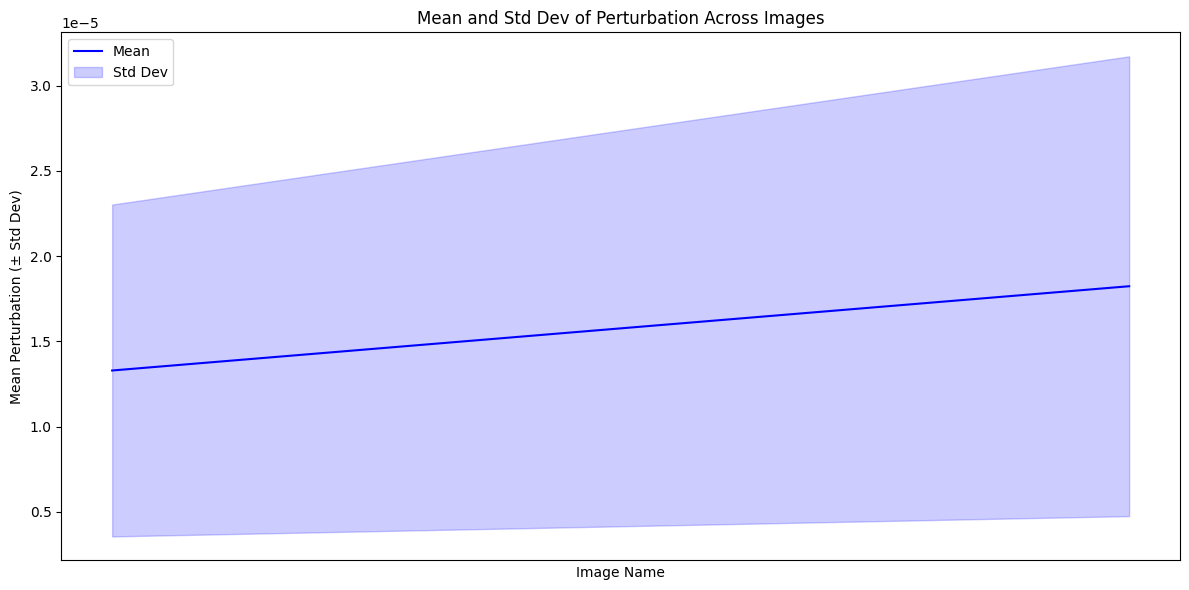

In [9]:
# Prepare data for plotting, filter out None values
img_names_sorted = []
means = []
stds = []
for name in sorted(img_name_mean_and_std_dev.keys()):
    mean = img_name_mean_and_std_dev[name]["mean"]
    std = img_name_mean_and_std_dev[name]["std"]
    if mean is not None and std is not None:
        img_names_sorted.append(name)
        means.append(mean)
        stds.append(std)

plt.figure(figsize=(12, 6))
plt.plot(img_names_sorted, means, label='Mean', color='blue')
plt.fill_between(img_names_sorted,
                 np.array(means) - np.array(stds),
                 np.array(means) + np.array(stds),
                 color='blue', alpha=0.2, label='Std Dev')
plt.xlabel('Image Name')
plt.ylabel('Mean Perturbation (± Std Dev)')
plt.title('Mean and Std Dev of Perturbation Across Images')
plt.tick_params(
    axis='x',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    bottom=False,      # ticks along the bottom edge are off
    top=False,         # ticks along the top edge are off
    labelbottom=False) # labels along the bottom edge are off
plt.legend()
plt.tight_layout()
plt.show()

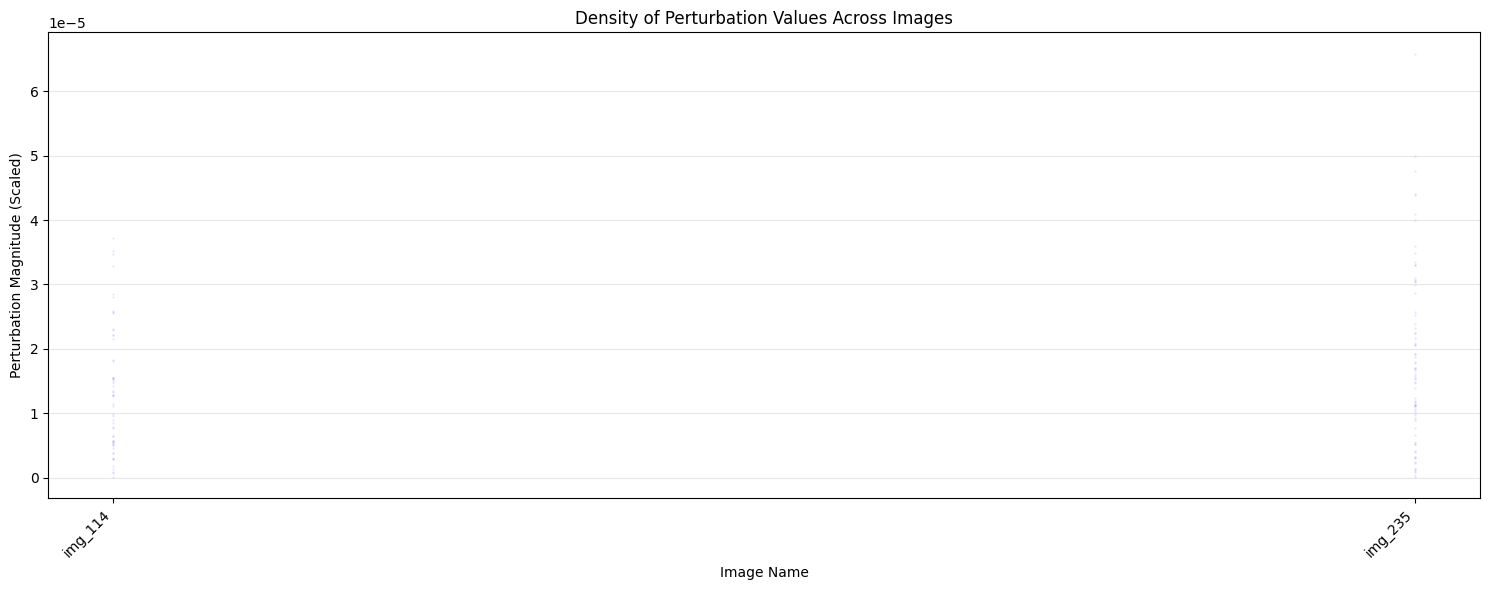

In [10]:
# Create a density scatter plot of all perturbation values
x_coords = []
y_values = []
valid_img_names = []

# Get sorted image names to maintain consistent x-axis order
sorted_all_img_names = sorted(img_name_mean_and_std_dev.keys())

# Index counter for the x-axis
current_x_idx = 0

for img_name in sorted_all_img_names:
    # Check if this image has valid data (based on your previous logic)
    if img_name_mean_and_std_dev[img_name]["mean"] is None:
        continue

    # Ensure image exists in the dataframe
    if img_name not in diff_df.columns:
        continue

    # Retrieve the raw dictionary of classes
    data_classes = diff_df[img_name]["classes"]

    # Collect all values across all classes for this image
    all_vals_img = []
    for class_idx in classes:
        if class_idx in data_classes:
            all_vals_img.extend(data_classes[class_idx])

    # Apply the same normalization/scaling logic as before
    # v / 3072 ** 0.5
    scale_factor = 3072 ** 0.5
    scaled_vals = [v / scale_factor for v in all_vals_img]

    # Take absolute value as done in the mean/std calculation
    abs_vals = np.abs(scaled_vals)

    # Append data for plotting
    # We assign the same x-coordinate (current_x_idx) to all points belonging to this image
    x_coords.extend([current_x_idx] * len(abs_vals))
    y_values.extend(abs_vals)

    valid_img_names.append(img_name)
    current_x_idx += 1

# Plotting
plt.figure(figsize=(15, 6))

# Use a high transparency (alpha) and small point size (s) to visualize density
plt.scatter(x_coords, y_values, s=1, alpha=0.05, color='blue', rasterized=True)

plt.xlabel('Image Name')
plt.ylabel('Perturbation Magnitude (Scaled)')
plt.title('Density of Perturbation Values Across Images')

# Adjust x-axis ticks to match the valid images indices
# Since there are many images, we only label a subset to avoid clutter
step = max(1, len(valid_img_names) // 20)
plt.xticks(
    ticks=np.arange(0, len(valid_img_names), step),
    labels=[valid_img_names[i] for i in range(0, len(valid_img_names), step)],
    rotation=45,
    ha='right'
)

# Optional: Match the style of the previous plot (no x-ticks on bottom)
# Uncomment the following lines if you prefer to hide the labels completely
# plt.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

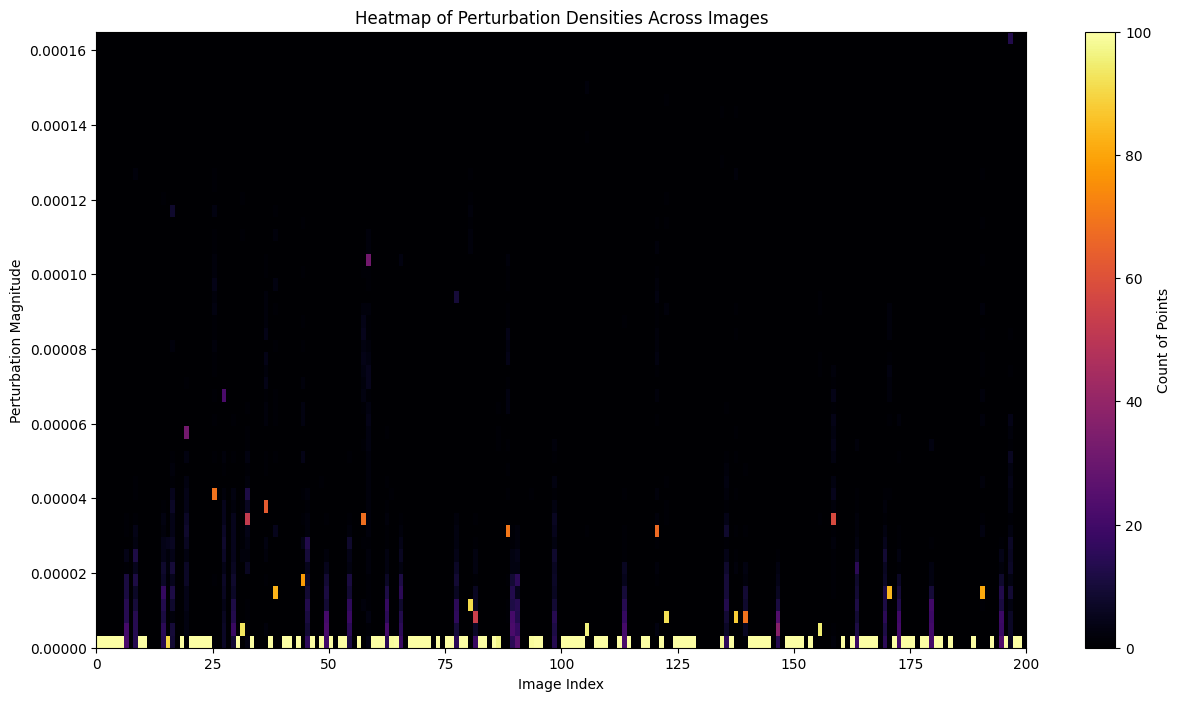

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Prepare Data
sorted_img_names = sorted([col for col in diff_df.columns if col.startswith('img_')])
all_image_values = []

# Collect data for all images first to determine global bin ranges
for img_name in sorted_img_names:
    if img_name not in diff_df.columns:
        continue

    # Extract values
    data_classes = diff_df[img_name]["classes"]
    vals = []
    for class_id in data_classes:
        vals.extend(data_classes[class_id])

    # Scale and Abs
    scale_factor = 3072 ** 0.5
    vals = np.abs(np.array(vals) / scale_factor)
    all_image_values.append(vals)

# 2. Create Bins
# Flatten all data to find global min/max
flat_data = np.concatenate(all_image_values)
n_bins = 50  # Resolution of the y-axis
bins = np.linspace(np.min(flat_data), np.max(flat_data), n_bins + 1)

# 3. Build Heatmap Matrix (Rows=Bins, Cols=Images)
heatmap_matrix = np.zeros((n_bins, len(all_image_values)))

for i, vals in enumerate(all_image_values):
    # Histogram for this specific image
    hist, _ = np.histogram(vals, bins=bins)
    heatmap_matrix[:, i] = hist

# 4. Plot
plt.figure(figsize=(15, 8))
# Log scale for color can help if some bins are very dense compared to others
plt.imshow(heatmap_matrix, aspect='auto', origin='lower', cmap='inferno', interpolation='nearest',
           extent=[0, len(all_image_values), bins[0], bins[-1]])

plt.colorbar(label='Count of Points')
plt.xlabel('Image Index')
plt.ylabel('Perturbation Magnitude')
plt.title('Heatmap of Perturbation Densities Across Images')
plt.grid(False)
plt.show()

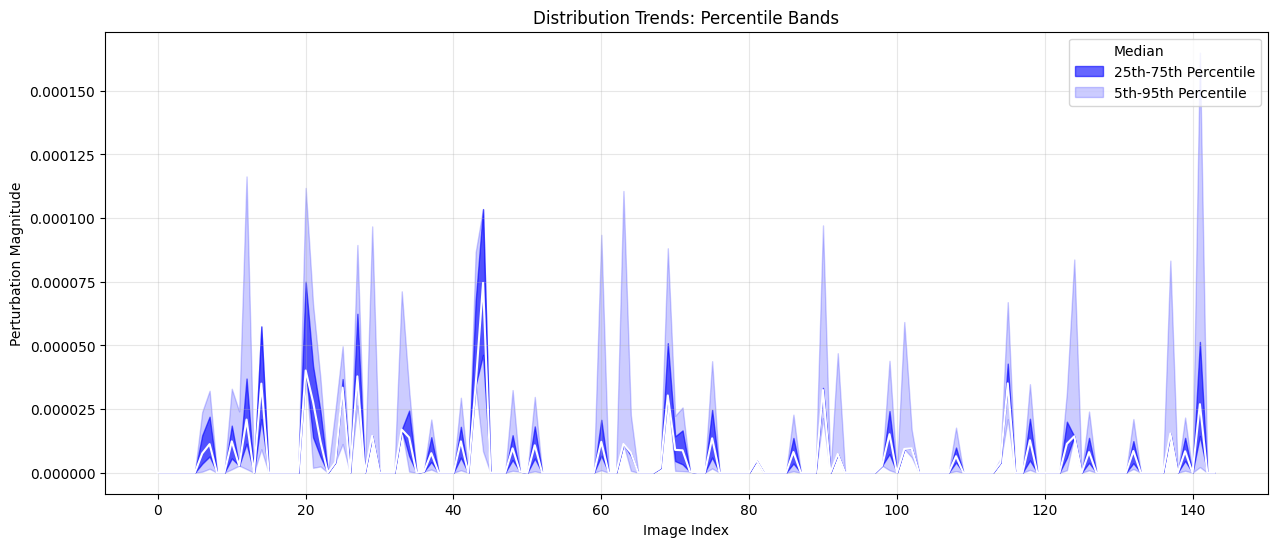

In [12]:
# Initialize lists for percentiles
p05, p25, p50, p75, p95 = [], [], [], [], []
valid_indices = []

for i, vals in enumerate(all_image_values):
    if len(vals) == 0: continue

    # Calculate percentiles
    percs = np.percentile(vals, [5, 25, 50, 75, 95])
    p05.append(percs[0])
    p25.append(percs[1])
    p50.append(percs[2])
    p75.append(percs[3])
    p95.append(percs[4])
    valid_indices.append(i)

plt.figure(figsize=(15, 6))
x_axis = range(len(valid_indices))

# Plot Median
plt.plot(x_axis, p50, color='white', linewidth=1.5, label='Median')

# Fill areas
plt.fill_between(x_axis, p25, p75, color='blue', alpha=0.6, label='25th-75th Percentile')
plt.fill_between(x_axis, p05, p95, color='blue', alpha=0.2, label='5th-95th Percentile')

plt.xlabel('Image Index')
plt.ylabel('Perturbation Magnitude')
plt.title('Distribution Trends: Percentile Bands')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

/tmp/ipykernel_2578784/731436836.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(subset_data, labels=subset_labels, patch_artist=True,


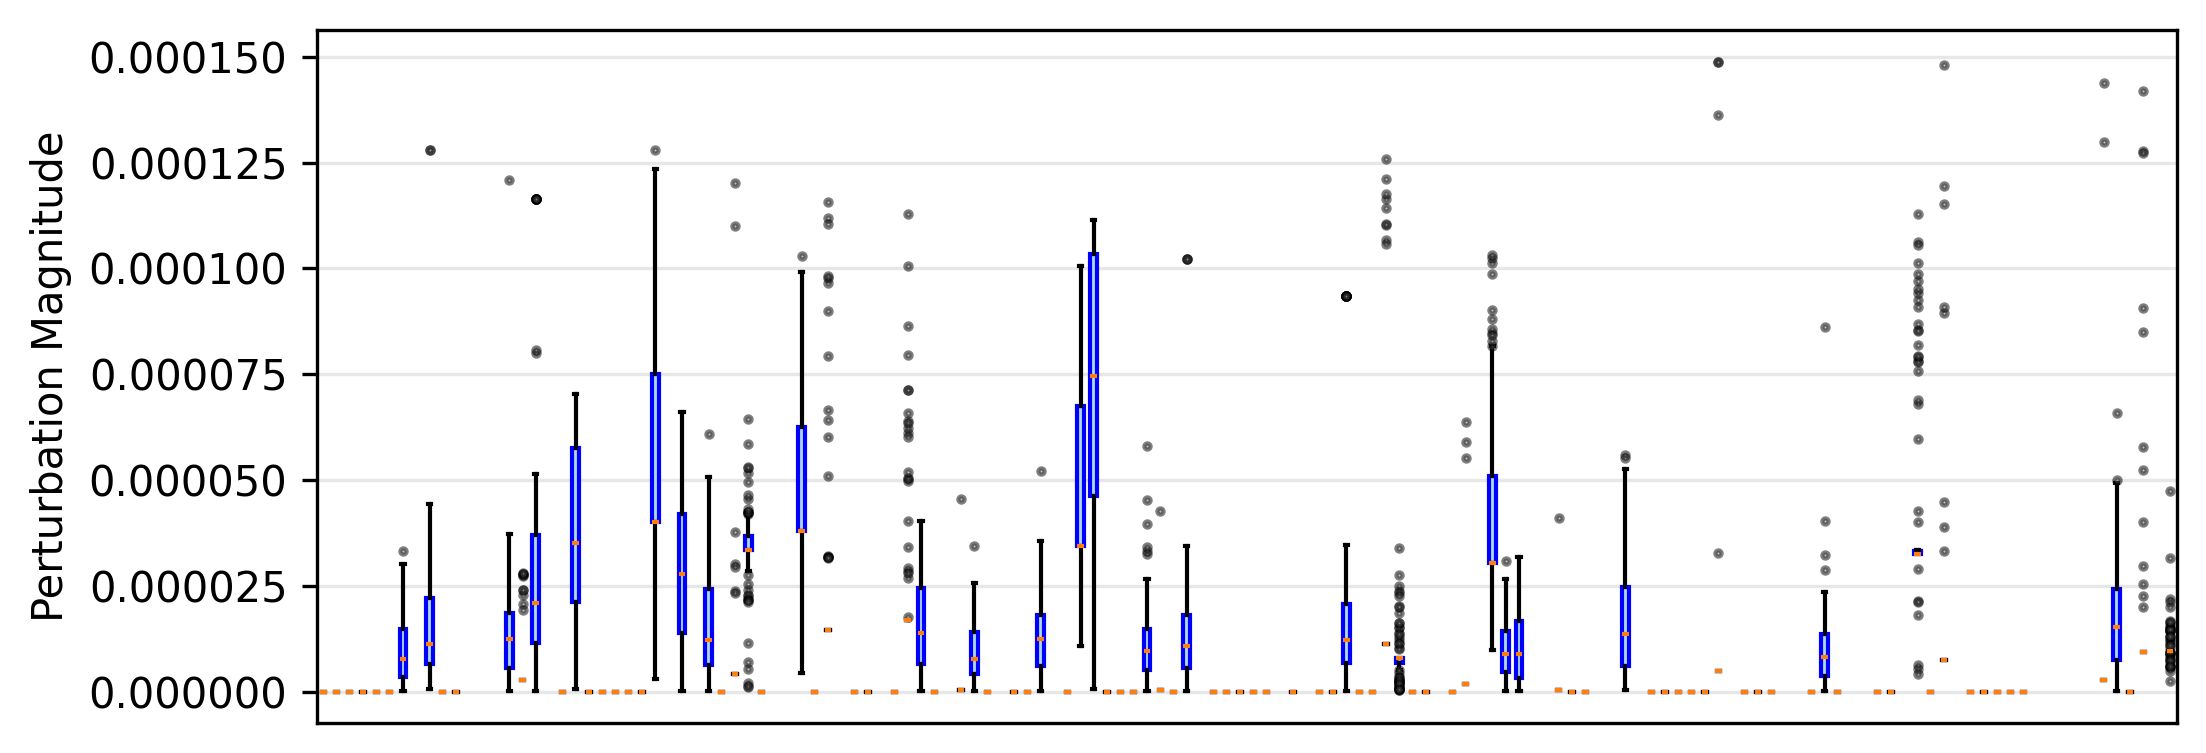

In [15]:
# Select every 10th image to avoid overcrowding
step = 1
subset_indices = range(0, len(all_image_values), step)
subset_indices = range(0, int(len(all_image_values)*.7))
subset_data = [all_image_values[i] for i in subset_indices]
subset_labels = [sorted_img_names[i] for i in subset_indices]

plt.figure(figsize=(8, 3), dpi=300)

# Create boxplot
# flierprops controls the style of the outliers (the dots)
plt.boxplot(subset_data, labels=subset_labels, patch_artist=True,
            boxprops=dict(facecolor="lightblue", color="blue"),
            # medianprops=dict(color="red"),
            flierprops=dict(marker='.', markerfacecolor='gray', markersize=3, alpha=0.5))

# plt.xticks(rotation=45, ha='right')
plt.gca().set_xticks([])  # Hide x-ticks to reduce clutter, since we have many images
# plt.xlabel('Image Name')
plt.ylabel('Perturbation Magnitude')
# plt.title(f'Boxplot Distribution (Every {step}th Image)')
plt.grid(True, axis='y', alpha=0.3)
plt.show()

/tmp/ipykernel_2578784/392045105.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(subset_data, labels=subset_labels, patch_artist=True,


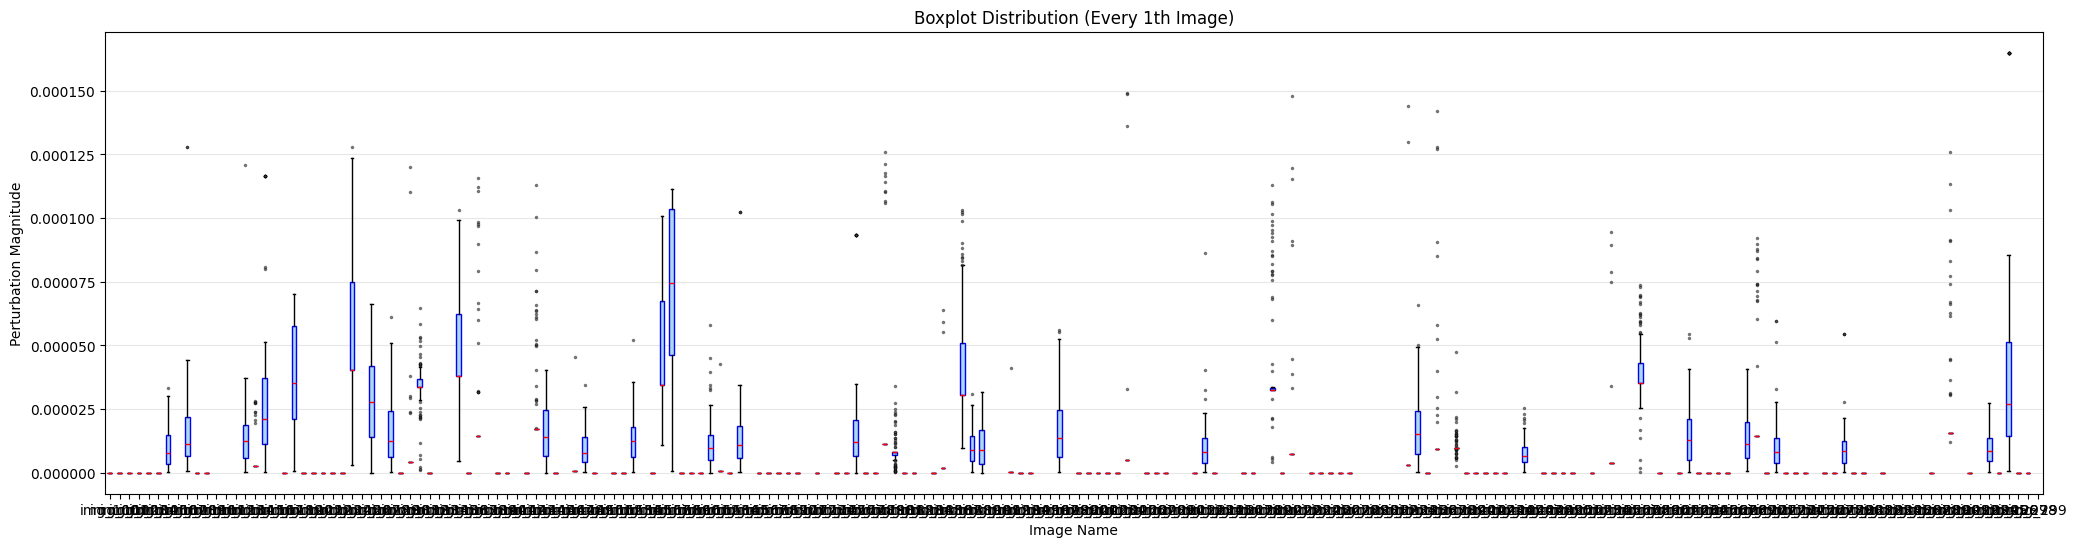

In [14]:
# Select every 10th image to avoid overcrowding
step = 1
subset_indices = range(0, len(all_image_values), step)
subset_data = [all_image_values[i] for i in subset_indices]
subset_labels = [sorted_img_names[i] for i in subset_indices]

plt.figure(figsize=(25, 6))

# Create boxplot
# flierprops controls the style of the outliers (the dots)
plt.boxplot(subset_data, labels=subset_labels, patch_artist=True,
            boxprops=dict(facecolor="lightblue", color="blue"),
            medianprops=dict(color="red"),
            flierprops=dict(marker='.', markerfacecolor='gray', markersize=3, alpha=0.5))

# plt.xticks(rotation=45, ha='right')
plt.xlabel('Image Name')
plt.ylabel('Perturbation Magnitude')
plt.title(f'Boxplot Distribution (Every {step}th Image)')
plt.grid(True, axis='y', alpha=0.3)
plt.show()